In [34]:
suppressMessages(library(ArchR))
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(dplyr))
suppressMessages(library(tidyr))
suppressMessages(library(cowplot))
suppressMessages(library(future))

In [35]:
out_dir <- "../../results/04_single_cell_access_atac/11_create_seurat"

if(!dir.exists(out_dir)){
    dir.create(out_dir, recursive = TRUE)
}

In [36]:
proj <- loadArchRProject("../../results/04_single_cell_access_atac/10_create_archr_project", 
showLogo = FALSE)
df <- as.data.frame(proj@cellColData)

Successfully loaded ArchRProject!



In [37]:
head(df)

,Sample,TSSEnrichment,ReadsInTSS,ReadsInPromoter,PromoterRatio,PassQC,NucleosomeRatio,nMultiFrags,nMonoFrags,nFrags,nDiFrags,DoubletScore,DoubletEnrichment,ReadsInPeaks,FRIP
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
mouse#GAGGCTCCAGAGTCGA,mouse,10.229,10326,33420,0.1420073,1,4.658300,35866,20796,117670,61008,227.8374,8.5,71761,0.3051712
mouse#CTGTATTTCGTATAGC,mouse,9.869,10102,33263,0.1442505,1,3.783669,34032,24102,115296,57162,323.3062,14.2,76906,0.3337036
mouse#TATCGAGGTAACGTAA,mouse,10.541,10338,33123,0.1436471,1,3.778984,34521,24125,115293,56647,323.3062,12.7,75636,0.3285122
mouse#CGCAGGTAGAACGTCG,mouse,9.835,8950,29135,0.1355709,1,4.227330,31524,20556,107453,55373,323.3062,12.1,63549,0.2960366
mouse#TTCTGTAGTATCCTTT,mouse,8.935,8194,27820,0.1300267,1,3.927591,32041,21710,106978,53227,153.5944,6.8,63975,0.2993655
mouse#GCTTGCTGTTGTGAGG,mouse,11.220,9678,30277,0.1502014,1,4.268308,29701,19131,100788,51956,323.3062,11.5,67739,0.3364074


In [53]:
mean(df$nFrags)

[1] 11228.17

In [38]:
atac.counts <- readRDS("../../results/04_single_cell_access_atac/10_create_archr_project/PeakMatrix.Rds")

In [39]:
dim(atac.counts)

[1] 139613   2024

In [40]:
# create ATAC assay and add it to the object
chrom_assay <- CreateChromatinAssay(
  counts = atac.counts,
  sep = c("_", "_"),
  min.features = 1, 
  min.cells = 10
)

obj <- CreateSeuratObject(
  counts = chrom_assay,
  assay = "ATAC",
  meta.data = df
)

In [41]:
obj

An object of class Seurat 
138953 features across 2024 samples within 1 assay 
Active assay: ATAC (138953 features, 0 variable features)
 2 layers present: counts, data

In [42]:
colnames(obj@meta.data)

[1] "orig.ident"        "nCount_ATAC"       "nFeature_ATAC"    
 [4] "Sample"            "TSSEnrichment"     "ReadsInTSS"       
 [7] "ReadsInPromoter"   "PromoterRatio"     "PassQC"           
[10] "NucleosomeRatio"   "nMultiFrags"       "nMonoFrags"       
[13] "nFrags"            "nDiFrags"          "DoubletScore"     
[16] "DoubletEnrichment" "ReadsInPeaks"      "FRIP"

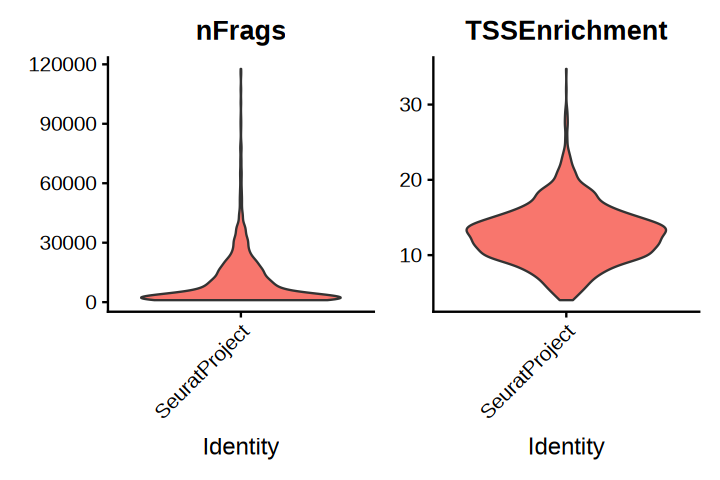

In [43]:
options(repr.plot.height = 4, repr.plot.width = 6)

VlnPlot(
  object = obj,
  features = c("nFrags", "TSSEnrichment"),
  ncol = 2,
  pt.size = 0
)

In [44]:
obj <- FindTopFeatures(obj, min.cutoff = "q1")

In [45]:
obj <- RunTFIDF(obj, method = 1)
obj <- RunSVD(obj, n = 30, scale.embeddings = TRUE)

Performing TF-IDF normalization



Running SVD

Scaling cell embeddings



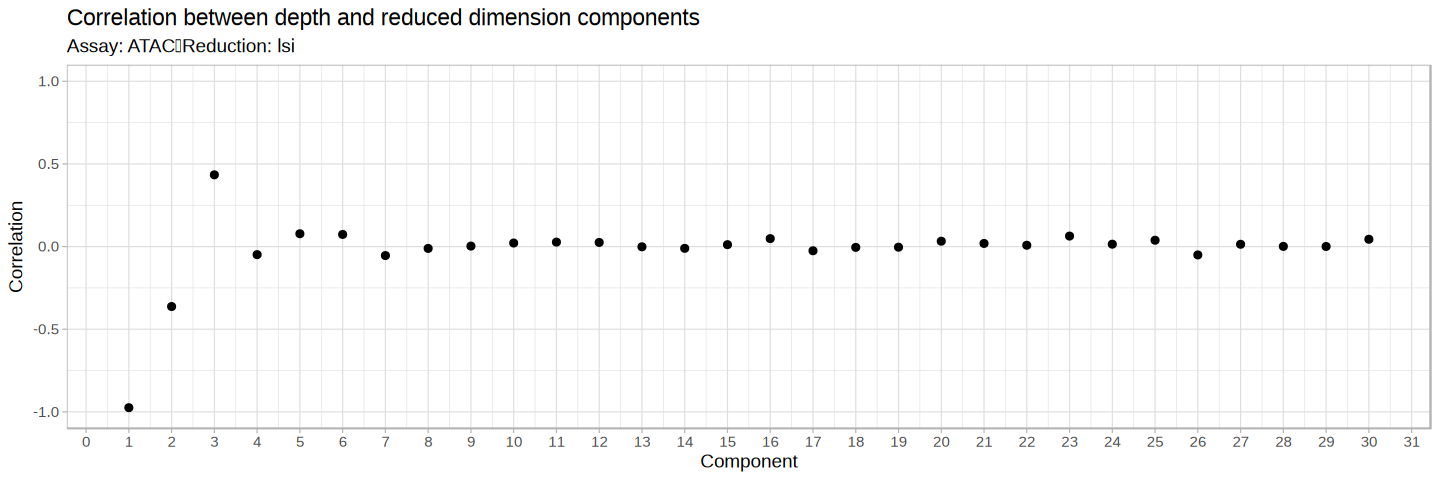

In [46]:
options(repr.plot.height = 4, repr.plot.width = 12)
DepthCor(obj, reduction = 'lsi', n = 30)

In [47]:
obj <- RunUMAP(object = obj, 
               reduction = 'lsi',
               reduction.name = "umap_atac",
               dims = 2:15, 
               metric = "euclidean",
               verbose = FALSE)

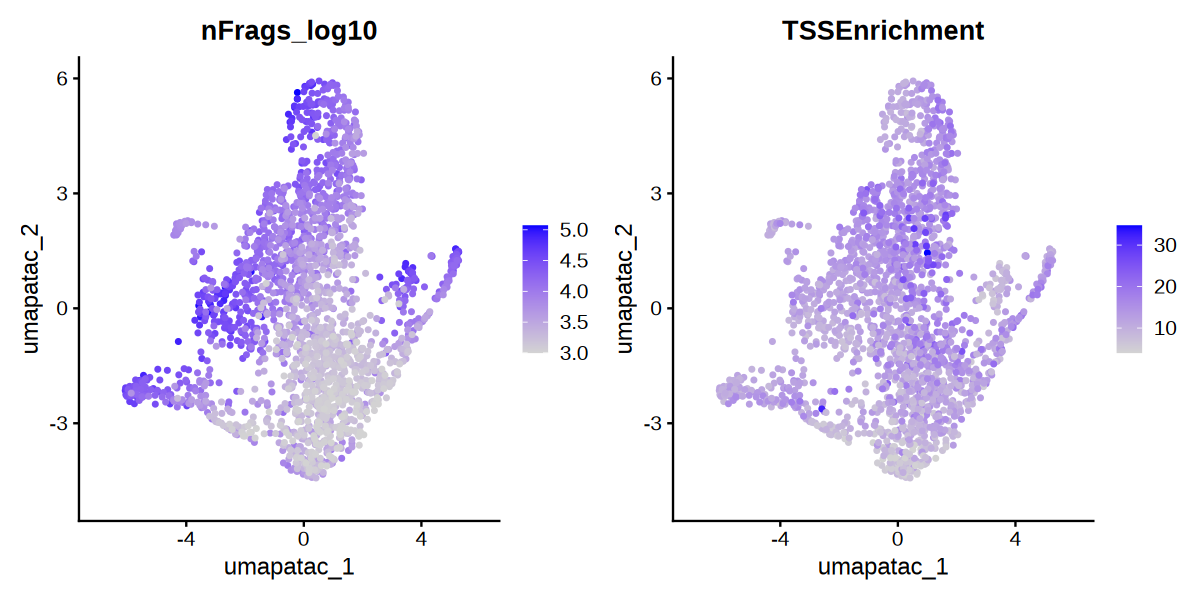

In [48]:
options(repr.plot.height = 5, repr.plot.width = 10)

obj@meta.data$nFrags_log10 <- log10(obj@meta.data$nFrags)

FeaturePlot(obj, reduction = "umap_atac", 
features = c("nFrags_log10", "TSSEnrichment"))

In [49]:
obj <- FindNeighbors(object = obj, reduction = 'lsi', dims = 2:15)

Computing nearest neighbor graph



Computing SNN



In [50]:
obj <- FindClusters(object = obj, verbose = FALSE, resolution = 0.3)

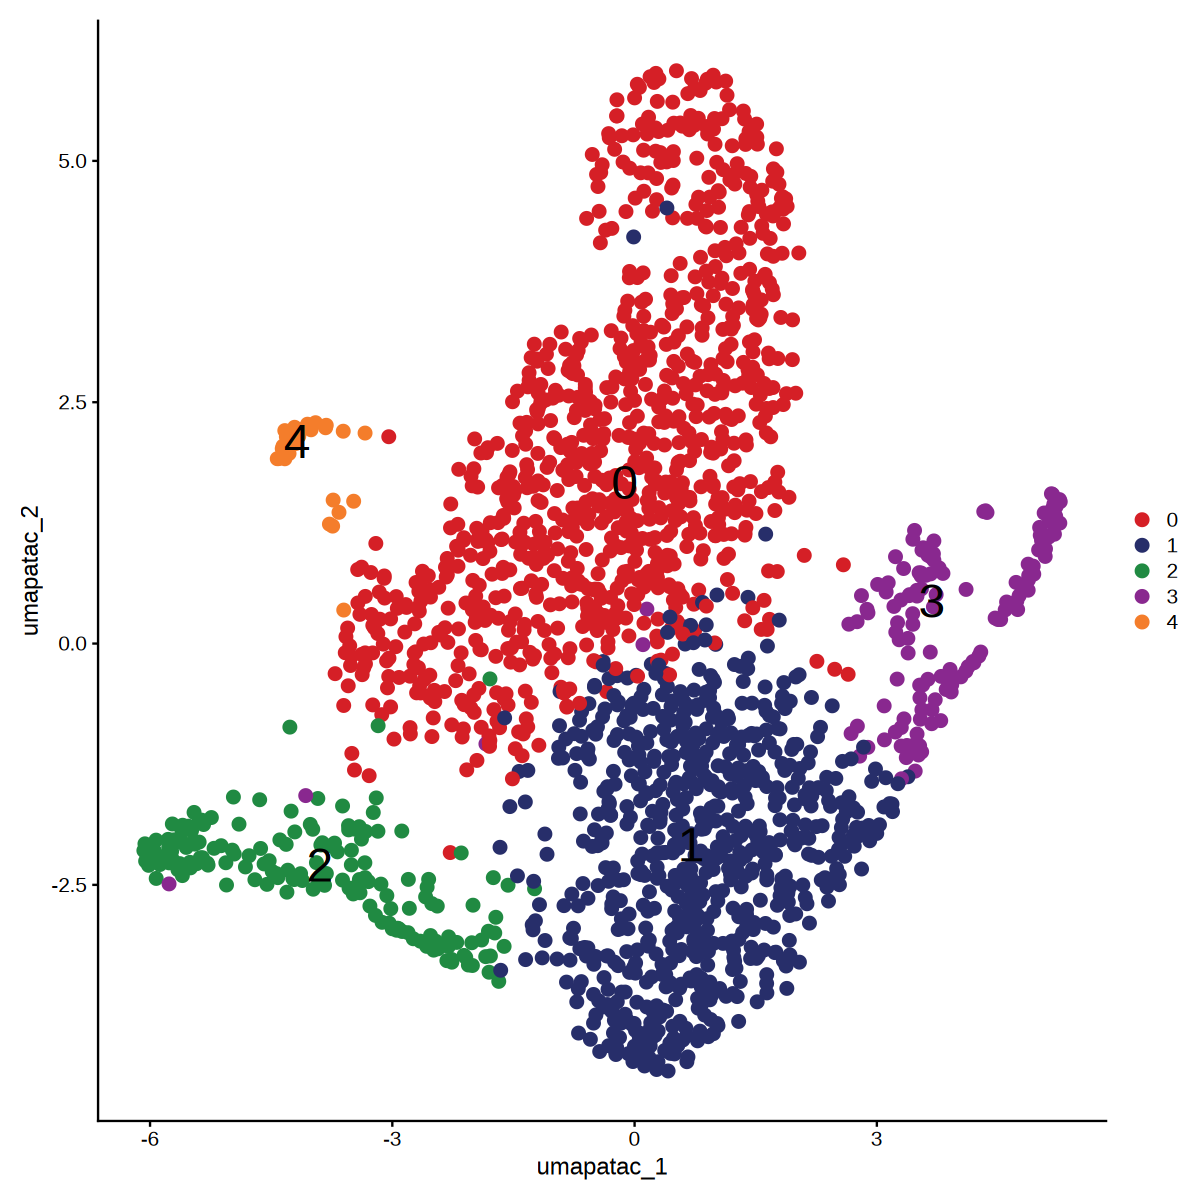

In [51]:
options(repr.plot.height = 10, repr.plot.width = 10)

DimPlot(object = obj, label = TRUE, label.size = 10, pt.size = 3, 
cols = ArchR::paletteDiscrete(obj$seurat_clusters))

In [52]:
saveRDS(obj, glue::glue("{out_dir}/obj.rds"))